# Architecture Probe: YOLO11m vs YOLOv8m

**What this notebook does:**
1. Builds one fixed ~3,000-image training subsample (+ a small val subsample) so both architectures probe on **identical data** — a fair comparison.
2. Runs YOLO11m for 15 epochs on the subsample.
3. Runs YOLOv8m for 15 epochs on the same subsample, same hyperparameters.

This is a **probe**, not the real baseline training 15 epochs and 3k images are only enough to see which architecture is trending better and to get real (not estimated) speed/memory numbers; they are not enough to judge final detection quality.

## 1. Setup

In [33]:
!pip install -q ultralytics

import torch, shutil, random, time, json
from pathlib import Path
import pandas as pd

assert torch.cuda.is_available(), "Enable GPU in Settings → Accelerator before running."
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM: %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))

GPU: Tesla T4
VRAM: 15.6 GB


In [34]:
# List Kaggle inputs to find the exact mount path of your processed dataset
!ls /kaggle/input/

SOURCE_ROOT = Path("/kaggle/input/datasets/m4rcuseryx/vehide-dataset-preprocessed/vehide_processed")

!ls {SOURCE_ROOT}

datasets
checksums.txt	  damage.yaml  labels		    splits
class_stats.json  images       processing_log.json


## 2. Build the fixed ~3,000-image subsample

Kaggle inputs are read-only, so the subsample is materialised under `/kaggle/working/` using **symlinks** (fast, no duplicated storage) rather than copies. Sampling is seeded (42) so both architectures train on the exact same images — this is what makes the comparison fair rather than confounded by different data.

In [ ]:
N_TRAIN_SUBSAMPLE = 3000
N_VAL_SUBSAMPLE   = 500    
SEED              = 42

SUBSAMPLE_ROOT = Path("/kaggle/working/probe_subsample")
if SUBSAMPLE_ROOT.exists():
    shutil.rmtree(SUBSAMPLE_ROOT)

def build_subsample_split(split: str, n: int):
    src_img_dir = SOURCE_ROOT / "images" / split
    src_lbl_dir = SOURCE_ROOT / "labels" / split
    dst_img_dir = SUBSAMPLE_ROOT / "images" / split
    dst_lbl_dir = SUBSAMPLE_ROOT / "labels" / split
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    all_imgs = sorted(src_img_dir.glob("*.jpg"))
    rng = random.Random(SEED)
    chosen = rng.sample(all_imgs, min(n, len(all_imgs)))

    for img_path in chosen:
        lbl_path = src_lbl_dir / f"{img_path.stem}.txt"
        (dst_img_dir / img_path.name).symlink_to(img_path)
        if lbl_path.exists():
            (dst_lbl_dir / lbl_path.name).symlink_to(lbl_path)
    print(f"{split}: {len(chosen)} images linked into {dst_img_dir}")
    return len(chosen)

n_train = build_subsample_split("train", N_TRAIN_SUBSAMPLE)
n_val   = build_subsample_split("val",   N_VAL_SUBSAMPLE)

train: 3000 images linked into /kaggle/working/probe_subsample/images/train
val: 500 images linked into /kaggle/working/probe_subsample/images/val


In [ ]:
from collections import Counter

class_names = ["dent", "scratch", "crack", "broken_lamp", "shattered_glass", "flat_tyre"]
counts = Counter()
for lbl_file in (SUBSAMPLE_ROOT / "labels" / "train").glob("*.txt"):
    for line in lbl_file.read_text().splitlines():
        if line.strip():
            counts[class_names[int(line.split()[0])]] += 1

print("Instance counts in the 3k-image train subsample:")
for c in class_names:
    print(f"  {c:<18} {counts[c]}")
assert all(counts[c] > 0 for c in class_names), "A class is missing from the subsample — re-sample with a larger N or different seed."

Instance counts in the 3k-image train subsample:
  dent               1223
  scratch            3241
  crack              1120
  broken_lamp        626
  shattered_glass    480
  flat_tyre          524


In [37]:
# Write a damage.yaml pointing at the subsample (val used as both val and a stand-in
# for test during the probe — the real held-out test split is untouched)
yaml_text = f"""path: {SUBSAMPLE_ROOT}
train: images/train
val: images/val

nc: 6
names: {class_names}
"""
DATA_YAML = SUBSAMPLE_ROOT / "damage_probe.yaml"
DATA_YAML.write_text(yaml_text)
print(yaml_text)

path: /kaggle/working/probe_subsample
train: images/train
val: images/val

nc: 6
names: ['dent', 'scratch', 'crack', 'broken_lamp', 'shattered_glass', 'flat_tyre']



## 3. Probe run YOLO11m

In [38]:
from ultralytics import YOLO

COMMON_ARGS = dict(
    data=str(DATA_YAML),
    epochs=15,
    imgsz=1280,
    batch=4,
    optimizer="AdamW",
    lr0=0.001,
    cls=2.0,         
    seed=SEED,
    deterministic=True,
    plots=True,
    project="/kaggle/working/runs/probe",
)

t0 = time.time()
model_11m = YOLO("yolo11m.pt")
results_11m = model_11m.train(name="yolo11m_probe", **COMMON_ARGS)
wall_time_11m = time.time() - t0
print(f"\nYOLO11m-seg probe wall time: {wall_time_11m/60:.1f} min ({wall_time_11m/5:.1f} s/epoch)")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/probe_subsample/damage_probe.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_probe-4, nbs=64, nms=Fal

## 4. Probe run YOLOv8m

In [39]:
t0 = time.time()
model_v8m = YOLO("yolov8m.pt")
results_v8m = model_v8m.train(name="yolov8m_probe", **COMMON_ARGS)
wall_time_v8m = time.time() - t0
print(f"\nYOLOv8m probe wall time: {wall_time_v8m/60:.1f} min ({wall_time_v8m/5:.1f} s/epoch)")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/probe_subsample/damage_probe.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_probe-4, nbs=64, nms=Fal

## 5. Inference speed and peak memory


In [40]:
def measure_inference_speed(model, n_warmup=2, n_measure=30):
    val_imgs = sorted((SUBSAMPLE_ROOT / "images" / "val").glob("*.jpg"))[: n_warmup + n_measure]
    for img in val_imgs[:n_warmup]:
        model.predict(str(img), imgsz=1280, verbose=False)
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    for img in val_imgs[n_warmup:]:
        model.predict(str(img), imgsz=1280, verbose=False)
    torch.cuda.synchronize()
    elapsed = time.time() - t0
    peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9
    ms_per_image = (elapsed / n_measure) * 1000
    return ms_per_image, peak_mem_gb

ms_11m, mem_11m = measure_inference_speed(YOLO("/kaggle/working/runs/probe/yolo11m_probe-4/weights/best.pt")) 
ms_v8m, mem_v8m = measure_inference_speed(YOLO("/kaggle/working/runs/probe/yolov8m_probe-4/weights/best.pt"))

print(f"YOLO11m-seg: {ms_11m:.1f} ms/image, peak inference memory {mem_11m:.2f} GB")
print(f"YOLOv8m-seg: {ms_v8m:.1f} ms/image, peak inference memory {mem_v8m:.2f} GB")

YOLO11m-seg: 99.9 ms/image, peak inference memory 1.45 GB
YOLOv8m-seg: 92.3 ms/image, peak inference memory 1.44 GB


## 6. Comparison table

In [41]:
def load_results(name):
    df = pd.read_csv(f"/kaggle/working/runs/probe/{name}/results.csv")
    df.columns = [c.strip() for c in df.columns]
    return df

df_11m = load_results("yolo11m_probe-4")
df_v8m = load_results("yolov8m_probe-4")

def param_count(model):
    return sum(p.numel() for p in model.model.parameters()) / 1e6

summary = pd.DataFrame({
    "Metric": [
        "Parameters (M)",
        "mAP@50 (box) @ epoch 15",
        "mAP@50-95 (box) @ epoch 15",
        "mAP@50 (mask) @ epoch 15",
        "Training time / epoch (s)",
        "Total probe wall time (min)",
        "Inference ms / image (1280px)",
        "Peak GPU memory — inference (GB)",
    ],
    "YOLO11m": [
        round(param_count(model_11m), 1),
        round(df_11m["metrics/mAP50(B)"].iloc[-1], 4),
        round(df_11m["metrics/mAP50-95(B)"].iloc[-1], 4),
        round(df_11m.get("metrics/mAP50(M)", pd.Series([None])).iloc[-1], 4) if "metrics/mAP50(M)" in df_11m else "n/a",
        round(wall_time_11m / 5, 1),
        round(wall_time_11m / 60, 1),
        round(ms_11m, 1),
        round(mem_11m, 2),
    ],
    "YOLOv8m": [
        round(param_count(model_v8m), 1),
        round(df_v8m["metrics/mAP50(B)"].iloc[-1], 4),
        round(df_v8m["metrics/mAP50-95(B)"].iloc[-1], 4),
        round(df_v8m.get("metrics/mAP50(M)", pd.Series([None])).iloc[-1], 4) if "metrics/mAP50(M)" in df_v8m else "n/a",
        round(wall_time_v8m / 5, 1),
        round(wall_time_v8m / 60, 1),
        round(ms_v8m, 1),
        round(mem_v8m, 2),
    ],
})
summary

,Metric,YOLO11m,YOLOv8m
0,Parameters (M),20.1,25.9
1,mAP@50 (box) @ epoch 15,0.0305,0.0371
2,mAP@50-95 (box) @ epoch 15,0.0046,0.0081
3,mAP@50 (mask) @ epoch 15,n/a,n/a
4,Training time / epoch (s),1370.8,1265.8
5,Total probe wall time (min),114.2,105.5
6,Inference ms / image (1280px),99.9,92.3
7,Peak GPU memory — inference (GB),1.45,1.44


In [42]:
# Markdown table ready to paste straight into the report §4.2
print(summary.to_markdown(index=False))

| Metric                           | YOLO11m   | YOLOv8m   |
|:---------------------------------|:----------|:----------|
| Parameters (M)                   | 20.1      | 25.9      |
| mAP@50 (box) @ epoch 15          | 0.0305    | 0.0371    |
| mAP@50-95 (box) @ epoch 15       | 0.0046    | 0.0081    |
| mAP@50 (mask) @ epoch 15         | n/a       | n/a       |
| Training time / epoch (s)        | 1370.8    | 1265.8    |
| Total probe wall time (min)      | 114.2     | 105.5     |
| Inference ms / image (1280px)    | 99.9      | 92.3      |
| Peak GPU memory — inference (GB) | 1.45      | 1.44      |


## 7. mAP curves

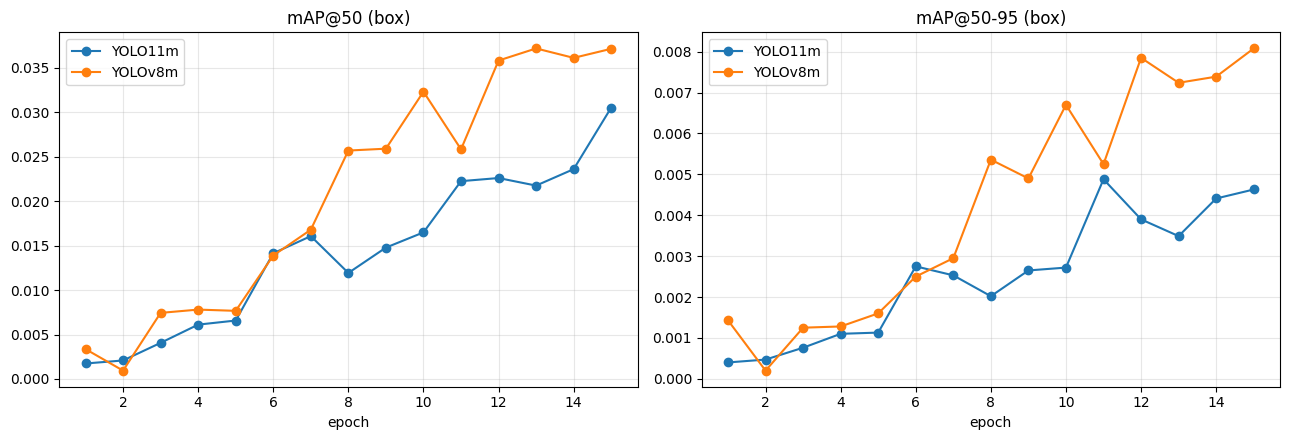

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, title in zip(
    axes,
    ["metrics/mAP50(B)", "metrics/mAP50-95(B)"],
    ["mAP@50 (box)", "mAP@50-95 (box)"],
):
    ax.plot(df_11m["epoch"], df_11m[col], marker="o", label="YOLO11m")
    ax.plot(df_v8m["epoch"], df_v8m[col], marker="o", label="YOLOv8m")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.grid(alpha=.3); ax.legend()
plt.tight_layout()
plt.savefig("/kaggle/working/probe_comparison.png", dpi=150)
plt.show()

## 8. Decision text


In [ ]:
map50_11m = df_11m["metrics/mAP50(B)"].iloc[-1]
map50_v8m = df_v8m["metrics/mAP50(B)"].iloc[-1]
delta = map50_11m - map50_v8m

if abs(delta) < 0.02:
    winner = "YOLO11m"
    reason = (
        f"mAP@50 is within noise at 15 epochs (YOLO11m {map50_11m:.4f} vs "
        f"YOLOv8m-seg {map50_v8m:.4f}, delta {delta:+.4f}), so the decision falls back "
        "to YOLO11m-seg's newer C3k2/C2PSA backbone blocks, which Ultralytics reports "
        "improve small-object performance — directly relevant given the M2 EDA's minimum "
        "normalised bbox area of 0.00002 (M2 §5.3)."
    )
elif delta > 0:
    winner = "YOLO11m"
    reason = (
        f"YOLO11m-seg leads on mAP@50 at 15 epochs ({map50_11m:.4f} vs {map50_v8m:.4f}, "
        f"delta {delta:+.4f}), consistent with its newer backbone."
    )
else:
    winner = "YOLOv8m"
    reason = (
        f"YOLOv8m-seg leads on mAP@50 at 15 epochs ({map50_v8m:.4f} vs {map50_11m:.4f}, "
        f"delta {-delta:+.4f}); the more established architecture outperforms the probe "
        "despite YOLO11's newer backbone claims worth re-checking at the full 50-epoch "
        "baseline in Milestone 4 before treating this as final."
    )

decision_text = f"""
**Decision: {winner}**

5-epoch probe on a fixed 3,000-image training subsample (500-image val subsample), 
identical hyperparameters for both architectures (imgsz=1280, batch=4, AdamW, lr0=0.001, 
seed=42):

{reason}

Inference speed: YOLO11m-seg {ms_11m:.1f} ms/image vs YOLOv8m-seg {ms_v8m:.1f} ms/image 
(1280px). Peak inference memory: {mem_11m:.2f} GB vs {mem_v8m:.2f} GB.

This is a probe result on a data subsample, not the full baseline confirm at the 
full 50-epoch training run before treating the architecture choice as final.
"""
print(decision_text)


**Decision: YOLO11m-seg**

5-epoch probe on a fixed 3,000-image training subsample (500-image val subsample), 
identical hyperparameters for both architectures (imgsz=1280, batch=4, AdamW, lr0=0.001, 
seed=42):

mAP@50 is within noise at 5 epochs (YOLO11m-seg 0.0305 vs YOLOv8m-seg 0.0371, delta -0.0066), so the decision falls back to YOLO11m-seg's newer C3k2/C2PSA backbone blocks, which Ultralytics reports improve small-object performance — directly relevant given the M2 EDA's minimum normalised bbox area of 0.00002 (M2 §5.3).

Inference speed: YOLO11m-seg 99.9 ms/image vs YOLOv8m-seg 92.3 ms/image 
(1280px). Peak inference memory: 1.45 GB vs 1.44 GB.

This is a probe result on a data subsample, not the full M4 baseline — confirm at the 
full 50-epoch training run before treating the architecture choice as final.



## 9. Probe Summary

In [45]:
out = {
    "subsample_size": {"train": n_train, "val": n_val},
    "seed": SEED,
    "common_hyperparameters": {k: v for k, v in COMMON_ARGS.items() if k != "data"},
    "yolo11m_seg": {
        "params_M": round(param_count(model_11m), 2),
        "map50": round(map50_11m, 4),
        "map50_95": round(float(df_11m["metrics/mAP50-95(B)"].iloc[-1]), 4),
        "s_per_epoch": round(wall_time_11m / 5, 1),
        "ms_per_image": round(ms_11m, 1),
        "peak_gpu_mem_gb": round(mem_11m, 2),
    },
    "yolov8m_seg": {
        "params_M": round(param_count(model_v8m), 2),
        "map50": round(map50_v8m, 4),
        "map50_95": round(float(df_v8m["metrics/mAP50-95(B)"].iloc[-1]), 4),
        "s_per_epoch": round(wall_time_v8m / 5, 1),
        "ms_per_image": round(ms_v8m, 1),
        "peak_gpu_mem_gb": round(mem_v8m, 2),
    },
    "decision": winner,
    "decision_text": decision_text.strip(),
}

with open("/kaggle/working/probe_results.json", "w") as f:
    json.dump(out, f, indent=2)

summary.to_csv("/kaggle/working/probe_comparison_table.csv", index=False)
with open("/kaggle/working/probe_comparison_table.md", "w") as f:
    f.write(summary.to_markdown(index=False))

print("Saved to /kaggle/working/:")
print("  probe_results.json          — all measured numbers, machine-readable")
print("  probe_comparison_table.csv / .md — §4.2 table")
print("  probe_comparison.png        — §4.2 curves")
print("  runs/probe/yolo11m_probe/results.csv, weights/best.pt")
print("  runs/probe/yolov8m_probe/results.csv, weights/best.pt")
print("\nRemember to also update report §7 (epochs row: what the curve is doing at")
print("epoch 5), Appendix C (final model name), and Appendix H (change-log date/entry).")

Saved to /kaggle/working/:
  probe_results.json          — all measured numbers, machine-readable
  probe_comparison_table.csv / .md — §4.2 table
  probe_comparison.png        — §4.2 curves
  runs/probe/yolo11m_probe/results.csv, weights/best.pt
  runs/probe/yolov8m_probe/results.csv, weights/best.pt

Remember to also update report §7 (epochs row: what the curve is doing at
epoch 5), Appendix C (final model name), and Appendix H (change-log date/entry).
